# Replikasi Eksperimen Giudici et al. (2020)
## *Network Models to Improve Automated Cryptocurrency Portfolio Management*

Notebook ini membandingkan strategi portofolio berikut:
1. **Equally Weighted (EW)** — Portofolio naif (1/N)
2. **Classical Markowitz (CM)** — Optimasi Mean-Variance tradisional
3. **Glasso Markowitz (GM)** — Markowitz dengan regularisasi Graphical Lasso
4. **Network Markowitz (NW)** — Integrasi Random Matrix Theory (RMT) + Minimum Spanning Tree (MST)
5. **Graph Diversification** — Diversifikasi berbasis Maximum Independent Set (MIS)
6. **AGGP** — Adaptive Graph-Gated Portfolio (model usulan)

---
## Sel 1 — Persiapan Library

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus pada dataset return harian untuk **10 aset kripto utama** dalam periode **14 September 2017 – 17 Oktober 2019**.

In [84]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")
print(f"Assets: {crypto_names}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00
Assets: ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']


---
## Sel 3 — Statistik Ringkasan (Table 1)

Menghasilkan tabel statistik deskriptif: **Mean, Std, Kurtosis, Skewness** untuk setiap aset kripto.

In [85]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal = 100 pada tanggal **7 Januari 2018**.

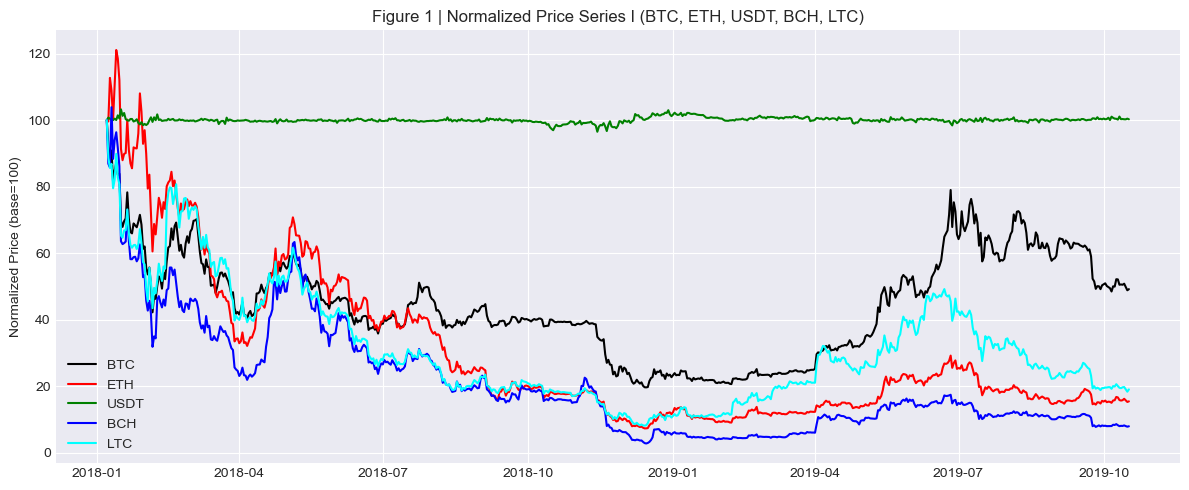

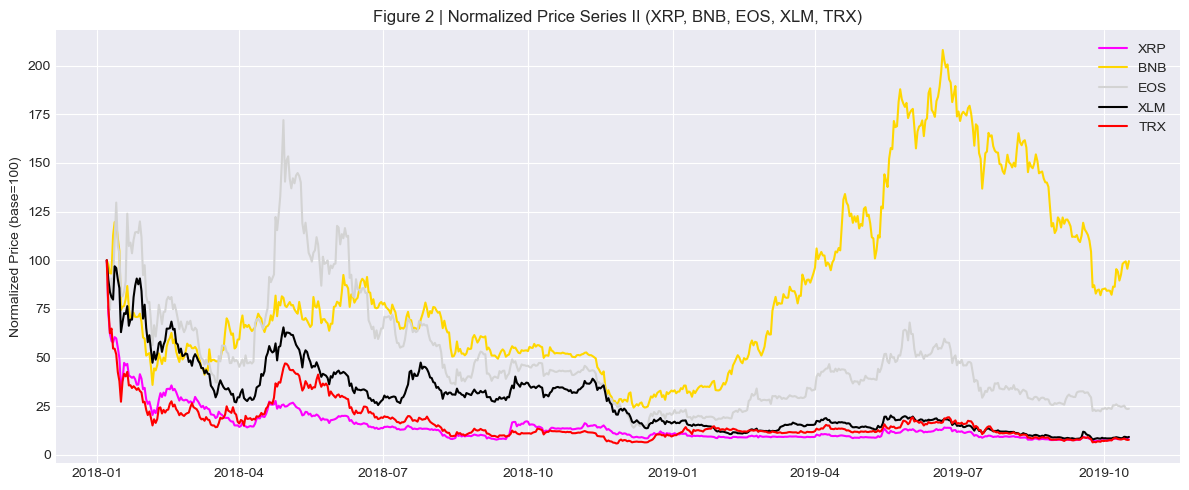

In [86]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1  = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100
colors_1  = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100
colors_2  = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 & 4 dari paper acuan:
- **Figure 3**: MST periode *Speculative Bubble* (Sep 2017 – Jan 2018)
- **Figure 4**: MST periode *Stable* (Jun 2019 – Okt 2019)

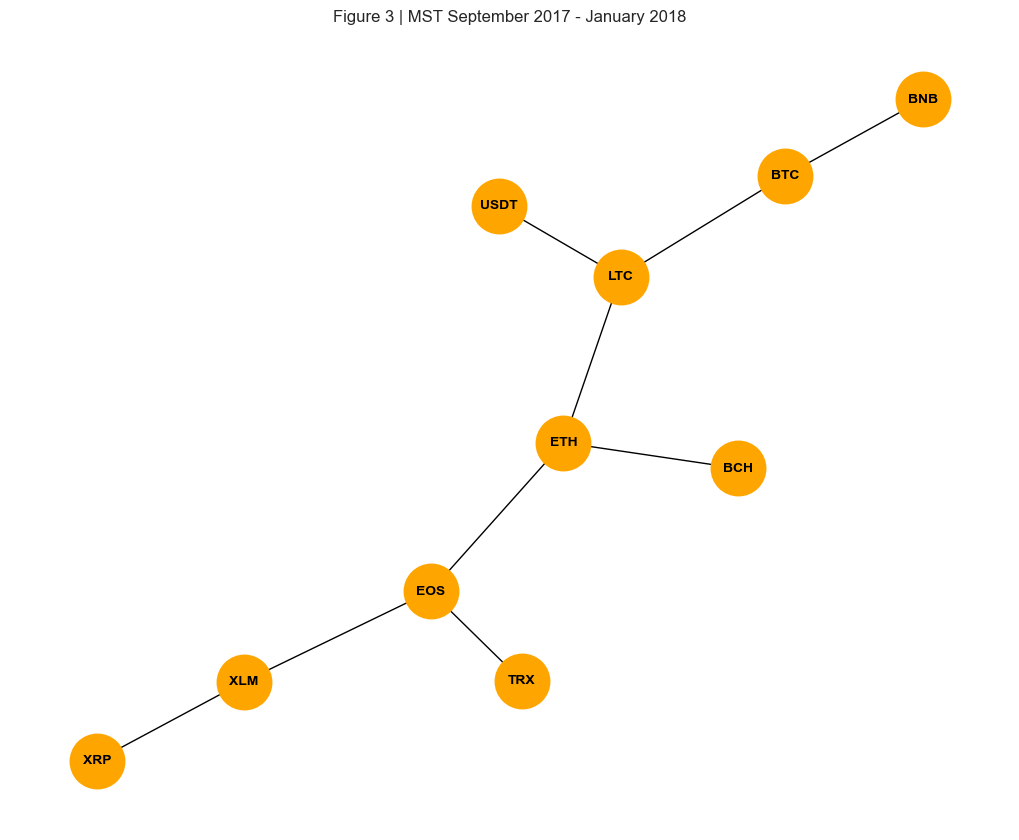

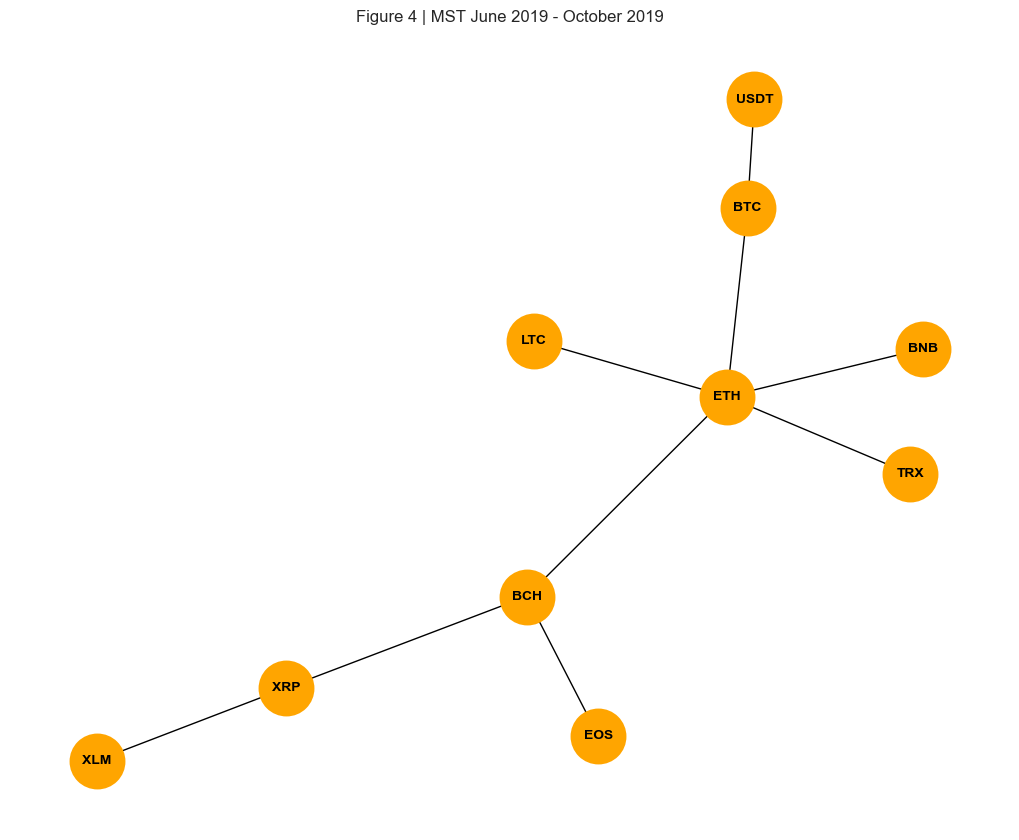

In [87]:
# --- Figure 3 | MST Speculative Bubble ---
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

# --- Figure 4 | MST Stable Period ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Implementasi:
- **`apply_rmt_filter`** — Filter noise matriks korelasi dengan *Random Matrix Theory*
- **`build_mst`** — Konstruksi matriks jarak untuk MST
- **`compute_eigenvector_centrality`** — Sentralitas eigenvector
- **`calculate_var`** — Value at Risk
- **`calculate_rachev_ratio`** — Rachev Ratio
- **`calculate_max_drawdown`** — Maximum Drawdown
- **`get_assets_graph_diversify`** — Seleksi aset via Maximum Independent Set
- **`get_assets_graph_diversify_rmt`** — MIS dengan filter RMT

In [88]:
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory (Marcenko-Pastur)."""
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus      = 1 + (1/Q) + 2*np.sqrt(1/Q)   # Marcenko-Pastur upper bound
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered  = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered       = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


def build_mst(correlation_matrix):
    """Bangun matriks jarak dari matriks korelasi."""
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    return centrality


def calculate_var(returns, confidence=0.95):
    """Hitung Value at Risk (VaR) pada tingkat kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Hitung Rachev Ratio = CVaR_upper(alpha) / CVaR_lower(alpha)."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Hitung Maximum Drawdown dari seri cumulative returns."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Seleksi aset independen menggunakan Maximum Independent Set (MIS)."""
    corr_mat = returns_window.corr()
    G        = nx.Graph()
    assets   = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """Seleksi aset independen menggunakan korelasi yang sudah difilter RMT."""
    assets = returns_window.columns.tolist()
    corr_f = apply_rmt_filter(returns_window)   # numpy array
    G      = nx.Graph()
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j and abs(corr_f[i, j]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New — Analisis Dinamika MST (Figure 5)

Analisis *rolling window* untuk menghitung **ambang batas MST** (*max link distance*) dan **koefisien residuality** sepanjang waktu.

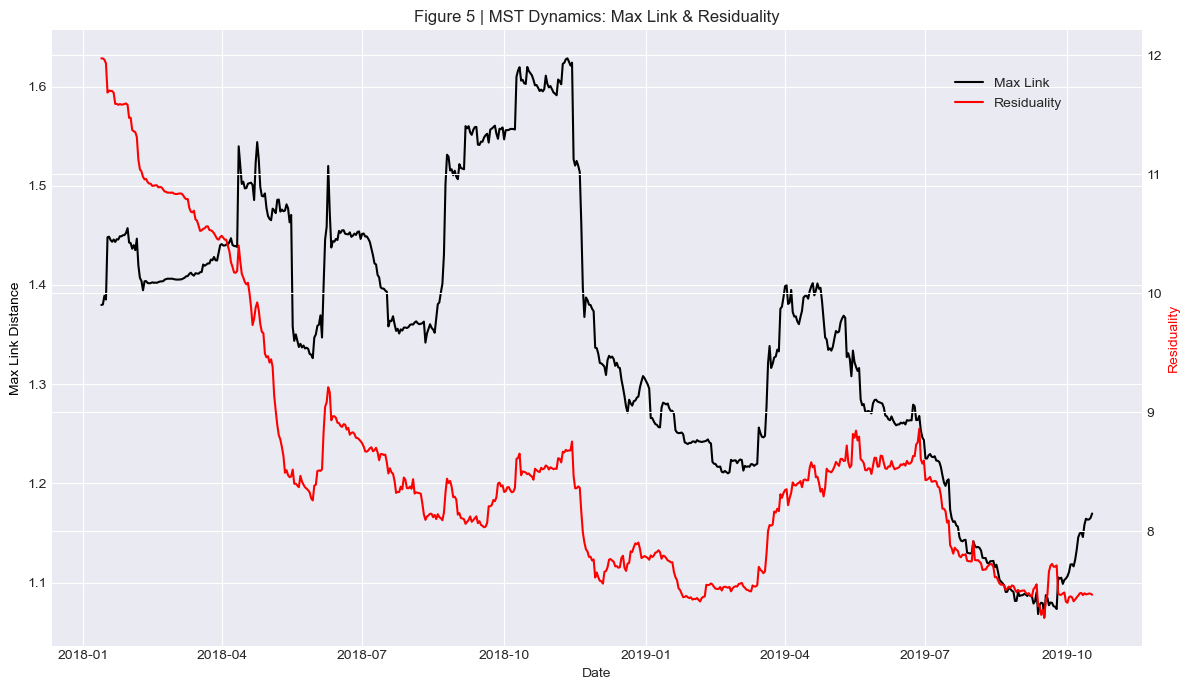

In [89]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []

    for i in range(window, len(returns_df)):
        window_data  = returns_df.iloc[i - window:i]
        corr_f       = apply_rmt_filter(window_data)
        mst_weights  = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(np.sum(mst_weights) / (returns_df.shape[1] - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


mst_dyn = calculate_rolling_mst_metrics(df_returns)

# Visualisasi dual axis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.set_xlabel('Date')
ax1.set_ylabel('Max Link Distance', color='black')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('Figure 5 | MST Dynamics: Max Link & Residuality')
plt.tight_layout()
plt.show()

---
## Sel 7 — Implementasi Strategi Portofolio

Setiap strategi diimplementasikan sebagai kelas yang mewarisi `PortfolioStrategy`.

In [90]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name            = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError


# ── 1. Equally Weighted ───────────────────────────────────────────────────────
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


# ── 2. Classical Markowitz ────────────────────────────────────────────────────
class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets    = returns_data.shape[1]
        mu          = returns_data.mean().values
        S           = returns_data.cov().values
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


# ── 3. Glasso Markowitz ───────────────────────────────────────────────────────
class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(returns_data.values)
            S = glasso.covariance_
        except Exception:
            S = returns_data.cov().values
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


# ── 4. Network Markowitz ──────────────────────────────────────────────────────
class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector (gamma)."""
    def __init__(self, name='Network Markowitz', gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values
        sig      = returns_data.std().values
        Cf       = apply_rmt_filter(returns_data)
        dist     = build_mst(Cf)
        cent     = compute_eigenvector_centrality(dist)
        Sf       = np.outer(sig, sig) * Cf
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


# ── 5. Graph Diversification ──────────────────────────────────────────────────
class GraphDiversification(PortfolioStrategy):
    """Strategi diversifikasi berbasis graf (Maximum Independent Set)."""
    def __init__(self, name='Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


# ── 6. RMT Graph Diversification ─────────────────────────────────────────────
class RMTGraphDiversification(PortfolioStrategy):
    """Graph Diversification dengan korelasi yang sudah difilter RMT."""
    def __init__(self, name='RMT Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify_rmt(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


# ── 7. Adaptive Graph-Gated Portfolio (AGGP) ──────────────────────────────────
class AdaptiveGraphPortfolio(PortfolioStrategy):
    """
    AGGP v1.2 (Fair V9): Menggabungkan Glasso Markowitz dan Network Markowitz
    secara adaptif berdasarkan densitas jaringan korelasi.
    gamma_max = 0.5 untuk profil risiko rendah.
    """
    def __init__(self, name='AGGP (Fair V9)', sensitivity=2.5, gamma_max=0.5):
        super().__init__(name)
        self.sensitivity = sensitivity
        self.gamma_max   = gamma_max

    def get_weights(self, r):
        n   = r.shape[1]
        mu  = r.mean().values
        sig = r.std().values
        try:
            glasso = GraphicalLassoCV(cv=5)
            glasso.fit(r.values)
            Sf = glasso.covariance_
            # Konversi covariance → korelasi agar sensor responsif
            v       = np.sqrt(np.diag(Sf))
            inv_sig = np.diag(1.0 / (v + 1e-8))
            Cf      = inv_sig @ Sf @ inv_sig
        except Exception:
            Cf = apply_rmt_filter(r)
            Sf = np.outer(sig, sig) * Cf

        # Sensor: densitas jaringan korelasi riil (threshold > 0.5)
        adj     = (np.abs(Cf) > 0.5).astype(int)
        G       = nx.from_numpy_array(adj)
        density = nx.density(G)

        # Gamma adaptif — dibatasi gamma_max untuk profil defensif
        gamma_t = np.clip(density * self.sensitivity, 0.1, self.gamma_max)

        dist  = build_mst(Cf)
        cent  = compute_eigenvector_centrality(dist)
        w_net = 1.0 / (cent + 1e-6)
        w_net /= w_net.sum()

        res_mko = minimize(
            lambda w: w @ Sf @ w,
            np.ones(n) / n,
            method='SLSQP',
            bounds=[(0, 1)] * n,
            constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        )
        return (1 - gamma_t) * res_mko.x + gamma_t * w_net


print("All portfolio strategy classes defined successfully!")

All portfolio strategy classes defined successfully!


---
## Sel 8 — Framework Backtesting

Sistem pengujian menggunakan **rolling window** dengan:
- `window_size = 120` hari
- `rebalance_freq = 7` hari
- `transaction_cost = 0.1%` (10 basis points)

In [91]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    """Simulasi backtest dengan rolling window dan biaya transaksi."""
    portfolio_returns = []
    dates             = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train = df_returns.iloc[i - window_size:i]
        w     = strategy.get_weights(train)

        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }


print("Backtest framework ready!")

Backtest framework ready!


---
## Sel 9 — Eksekusi Backtesting

Menjalankan backtest untuk semua strategi, termasuk berbagai nilai penalti $\gamma$ pada Network Markowitz.

In [92]:
# --- Inisialisasi semua strategi ---
gamma_values = [0.005, 0.025, 0.05, 0.15, 0.7, 1.0]

strategies = (
    [
        EquallyWeighted("EW"),
        ClassicalMarkowitz("CM"),
        GlassoMarkowitz("GM"),
        NetworkMarkowitz("NW (gamma=0)", gamma=0),
    ]
    + [NetworkMarkowitz(f"NW (gamma={g})", gamma=g) for g in gamma_values]
    + [
        GraphDiversification('Graph Divers. (theta=0.4)', corr_threshold=0.4),
        GraphDiversification('Graph Divers. (theta=0.5)', corr_threshold=0.5),
        RMTGraphDiversification('RMT GD (theta=0.4)',     corr_threshold=0.4),
        AdaptiveGraphPortfolio('AGGP (Optimized)',         sensitivity=2.0),
    ]
)

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Running: {strat.name} ...", end=' ')
    results[strat.name] = backtest_strategy(strat, df_returns)
    print("Done")

print("\nAll backtests completed!")

Running: EW ... Done
Running: CM ... Done
Running: GM ... Done
Running: NW (gamma=0) ... Done
Running: NW (gamma=0.005) ... Done
Running: NW (gamma=0.025) ... Done
Running: NW (gamma=0.05) ... Done
Running: NW (gamma=0.15) ... Done
Running: NW (gamma=0.7) ... Done
Running: NW (gamma=1.0) ... Done
Running: Graph Divers. (theta=0.4) ... Done
Running: Graph Divers. (theta=0.5) ... Done
Running: RMT GD (theta=0.4) ... Done
Running: AGGP (Optimized) ... Done

All backtests completed!


---
## Sel 10 — Analisis Performa Periodik (Table 2)

Tabel perbandingan **Cumulative Profits and Losses** yang disampel setiap periode Januari, Mei, dan September.

In [93]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 2 | Cumulative Profits and Losses (%)")
print(table2.to_string())

TABLE 2 | Cumulative Profits and Losses (%)
                           Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                                 
EW                         -35.53  -58.96  -77.02  -89.67  -77.88  -88.82
CM                         -34.32  -57.88  -59.66  -68.22  -55.67  -62.16
GM                         -33.86  -60.11  -61.90  -73.12  -62.49  -67.53
NW (gamma=0)               -41.59  -62.30  -63.81  -71.79  -61.83  -68.05
NW (gamma=0.005)           -41.62  -61.76  -64.22  -71.33  -62.41  -68.75
NW (gamma=0.025)           -44.13  -64.87  -66.29  -66.72  -57.08  -66.33
NW (gamma=0.05)            -44.80  -63.44  -64.60  -65.06  -55.14  -61.98
NW (gamma=0.15)            -44.65  -56.79  -58.18  -58.72  -46.94  -54.22
NW (gamma=0.7)             -40.13  -52.75  -54.21  -54.80  -41.90  -48.76
NW (gamma=1.0)             -39.09  -51.94  -53.57  -54.17  -41.10  -48.05
Graph Divers. (theta=0.4)  -38.42  -61.14  -67.67  -75.22  -54.08  -

---
## Sel 11 — Visualisasi Performa Kumulatif (Figure 6)

Evolusi nilai portofolio dengan asumsi investasi awal **100 USD** (periode 7 Januari 2018 – 17 Oktober 2019).

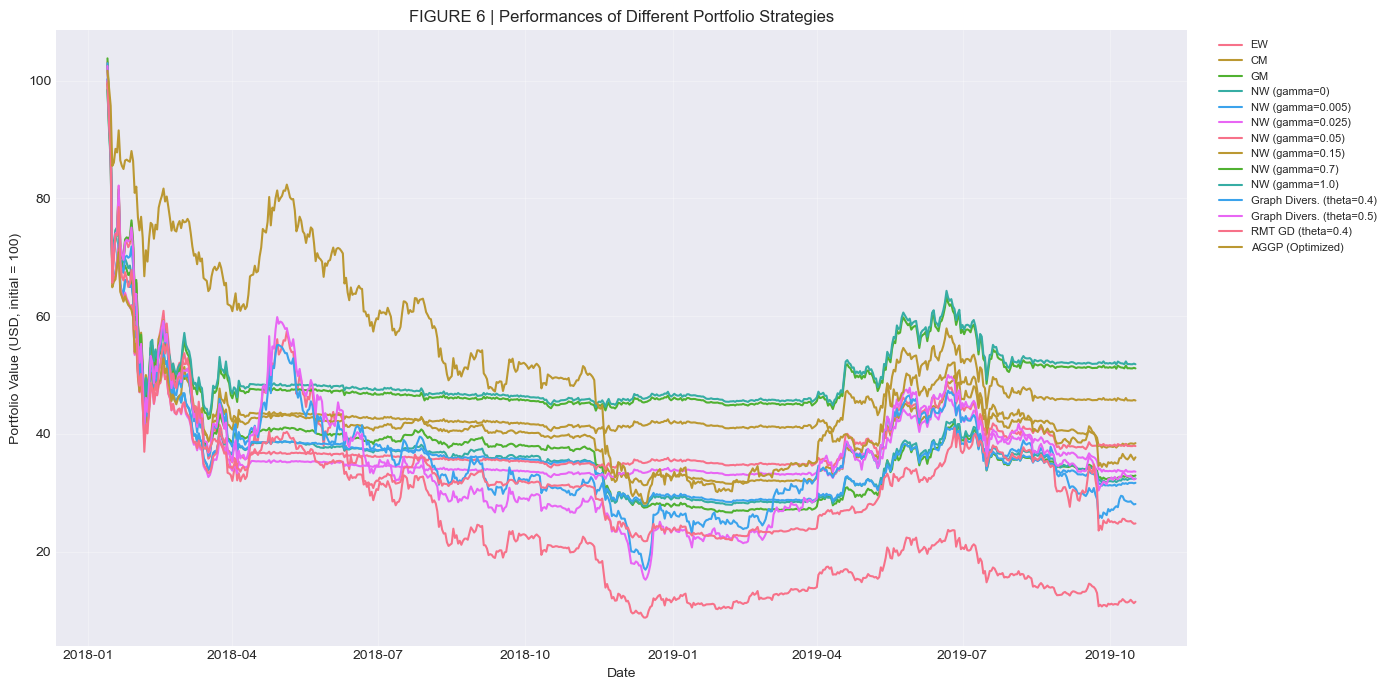

In [94]:
plt.figure(figsize=(14, 7))

for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)

plt.title('FIGURE 6 | Performances of Different Portfolio Strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD, initial = 100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sel 12 — Analisis Risiko Periodik: VaR (Table 3)

**Value at Risk** (VaR) pada tingkat kepercayaan 95%, dihitung pada jendela 4 bulan terakhir di setiap titik sampling. Nilai disajikan dalam bentuk absolut × 100.

In [95]:
# Strategi yang ditampilkan di Table 3
table3_strategies = ['EW', 'CM', 'GM', 'NW (gamma=0)', 'AGGP (Optimized)']

# Periode sampling (akhir setiap 4 bulan)
period_ends   = ['2018-01-31', '2018-05-31', '2018-09-30',
                 '2019-01-31', '2019-05-31', '2019-09-30']
period_labels = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

table3_rows = []
for strat_name in table3_strategies:
    if strat_name not in results:
        continue
    df_res = results[strat_name]['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td, label in zip(period_ends, period_labels):
        ts  = pd.Timestamp(td)
        ts0 = ts - pd.DateOffset(months=4)
        seg = df_res.loc[ts0:ts, 'return'].values
        var = abs(calculate_var(seg, 0.95)) * 100 if len(seg) > 0 else np.nan
        row[label] = round(var, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
print("TABLE 3 | VaR (95% confidence, scaled by 100)")
print(table3.to_string())

TABLE 3 | VaR (95% confidence, scaled by 100)
                   Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                         
EW                13.7904  9.5022  6.5259  9.4639  3.6718  8.0703
CM                12.8261  5.7940  0.9943  1.7249  1.6995  3.8047
GM                13.4648  5.9247  1.1848  2.4119  1.8105  4.1810
NW (gamma=0)      12.4709  5.5937  1.1435  1.8353  1.5132  3.9463
AGGP (Optimized)   6.7114  4.5532  3.6261  6.0901  2.9023  4.3440


---
## Sel 13 — Analisis Risk-Adjusted Return: Sharpe Ratio (Table 4)

**Sharpe Ratio** = Mean Return / Std Dev Return, dihitung pada jendela 4 bulan.

In [96]:
table4_strategies = ['EW', 'CM', 'GM', 'NW (gamma=0)', 'NW (gamma=0.15)', 'AGGP (Optimized)']

table4_rows = []
for strat_name in table4_strategies:
    if strat_name not in results:
        continue
    df_res = results[strat_name]['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td, label in zip(period_ends, period_labels):
        ts  = pd.Timestamp(td)
        ts0 = ts - pd.DateOffset(months=4)
        seg = df_res.loc[ts0:ts, 'return'].values
        sr  = (np.mean(seg) / np.std(seg)) if len(seg) > 1 and np.std(seg) > 0 else np.nan
        row[label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
print("TABLE 4 | Sharpe Ratio (4-month window)")
print(table4.to_string())

TABLE 4 | Sharpe Ratio (4-month window)
                  Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                        
EW               -0.2532 -0.0387 -0.0948 -0.1260  0.1955 -0.1282
CM               -0.2508 -0.0880 -0.0609 -0.1486  0.1886 -0.0633
GM               -0.2355 -0.0938 -0.0556 -0.1858  0.1743 -0.0559
NW (gamma=0)     -0.3442 -0.0942 -0.0546 -0.1498  0.1833 -0.0731
NW (gamma=0.15)  -0.4061 -0.0403 -0.0605 -0.0141  0.1556 -0.0632
AGGP (Optimized) -0.2828 -0.0353 -0.0932 -0.1478  0.1881 -0.1203


---
## Sel 14 — Analisis Tail-Risk: Rachev Ratio (Table 5)

**Rachev Ratio** = CVaR_upper(10%) / CVaR_lower(10%), mengukur asimetri distribusi return pada ekor.

In [97]:
table5_strategies = ['EW', 'CM', 'GM', 'NW (gamma=0)', 'NW (gamma=0.15)', 'AGGP (Optimized)']

table5_rows = []
for strat_name in table5_strategies:
    if strat_name not in results:
        continue
    df_res = results[strat_name]['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td, label in zip(period_ends, period_labels):
        ts  = pd.Timestamp(td)
        ts0 = ts - pd.DateOffset(months=4)
        seg = df_res.loc[ts0:ts, 'return'].values
        rr  = calculate_rachev_ratio(seg, alpha=0.10) if len(seg) > 0 else np.nan
        row[label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)")
print(table5.to_string())

TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)
                  Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                        
EW                0.3926  0.8936  0.8062  0.7200  1.7375  0.5455
CM                0.3969  0.7673  0.7865  0.6506  1.9847  0.7449
GM                0.4126  0.7528  0.7760  0.5600  1.6963  0.7247
NW (gamma=0)      0.2494  0.7707  0.7824  0.6389  2.0798  0.7792
NW (gamma=0.15)   0.1822  1.0056  0.8492  1.0171  2.1511  0.8379
AGGP (Optimized)  0.4117  0.9070  0.8027  0.6694  1.7851  0.5712


---
## Sel 15 — Analisis Fase Pasar (Table 6)

Perbandingan performa pada tiga kondisi pasar:
- **Bearish**: Januari 2018 – Maret 2019
- **Recovery**: April 2019 – Juni 2019
- **Stable/Sideways**: Juli 2019 – Oktober 2019

Tujuan: membuktikan **AGGP** sebagai *All-Terrain Model* yang adaptif.

In [98]:
# Definisi fase pasar
fase_pasar = {
    'Bearish':   ('2018-01-01', '2019-03-31'),
    'Recovery':  ('2019-04-01', '2019-06-30'),
    'Stable':    ('2019-07-01', '2019-10-17')
}

phase_strategies = ['EW', 'CM', 'GM', 'NW (gamma=0)', 'NW (gamma=0.15)', 'AGGP (Optimized)']

# ── Panel A: Sharpe Ratio per Fase ────────────────────────────────────────────
rows_sr = []
for phase, (start, end) in fase_pasar.items():
    row = {'Market Phase': phase}
    for strat_name in phase_strategies:
        if strat_name not in results:
            row[strat_name] = np.nan
            continue
        df_res = results[strat_name]['results_df'].set_index('date')
        seg    = df_res.loc[start:end, 'return'].values
        sr     = (np.mean(seg) / np.std(seg)) if len(seg) > 1 and np.std(seg) > 0 else np.nan
        row[strat_name] = round(sr, 4)
    rows_sr.append(row)

table6a = pd.DataFrame(rows_sr).set_index('Market Phase')
print("TABLE 6 | Panel A: Sharpe Ratio per Market Phase")
print(table6a.to_string())

# ── Panel B: Rachev Ratio per Fase ────────────────────────────────────────────
rows_rr = []
for phase, (start, end) in fase_pasar.items():
    row = {'Market Phase': phase}
    for strat_name in phase_strategies:
        if strat_name not in results:
            row[strat_name] = np.nan
            continue
        df_res = results[strat_name]['results_df'].set_index('date')
        seg    = df_res.loc[start:end, 'return'].values
        rr     = calculate_rachev_ratio(seg, alpha=0.10) if len(seg) > 0 else np.nan
        row[strat_name] = round(rr, 4)
    rows_rr.append(row)

table6b = pd.DataFrame(rows_rr).set_index('Market Phase')
print("\nTABLE 6 | Panel B: Rachev Ratio (alpha=10%) per Market Phase")
print(table6b.to_string())

TABLE 6 | Panel A: Sharpe Ratio per Market Phase
                  EW      CM      GM  NW (gamma=0)  NW (gamma=0.15)  AGGP (Optimized)
Market Phase                                                                         
Bearish      -0.0726 -0.0923 -0.0991       -0.1072          -0.0736           -0.0832
Recovery      0.1286  0.1844  0.1732        0.1763           0.1359            0.1471
Stable       -0.1301 -0.1022 -0.0950       -0.1095          -0.0743           -0.1267

TABLE 6 | Panel B: Rachev Ratio (alpha=10%) per Market Phase
                  EW      CM      GM  NW (gamma=0)  NW (gamma=0.15)  AGGP (Optimized)
Market Phase                                                                         
Bearish       0.7933  0.6463  0.6275        0.5982           0.6967            0.7697
Recovery      1.2168  1.2463  1.1627        1.2883           1.4069            1.4020
Stable        0.5712  0.7523  0.7477        0.7615           0.8315            0.5914
